# cGAN Training

### Goal - To build and train our **conditional GAN (cGAN)** - a generative model that learsn to create **synthetic handwriting images** conditioned on digit labels

## Plan 

1. Understand the architecture of a **conditional Gan (cGAN)**
2. Implement **Generator** and **discriminator** in pytorch
3. Train model with adversarial objectives
4. Visualise class-conditional handwriting samples

## Recap (cGAN)

A **Generative Adversarial Network (GAN)** consists of:
- A **Generator (G)** that creates fake samples from random noise.
- A **Discriminator (D)** that tries to tell real from fake.

In a **Conditional GAN**, both G and D receive an **additional input**: a *class label*.  
This allows the model to generate specific digits or characters on demand.

In [14]:
# import core libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

import os, sys

from data_utils.dataloader import get_mnist_loaders
from model.cgan import Generator, Discriminator
from utils.visualize import show_batch
from utils.checkpoint import save_checkpoint

device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f" Running on device: {device}")

 Running on device: cpu


### Define Model Hyperparameters 


We’ll use a low-dimensional latent space (`z_dim = 100`),  
and condition the model on **10 digit classes (0–9)**.

GANs are notoriously sensitive to hyperparameters —  
we’ll start simple and iterate.

In [15]:
# hyperparameters 
z_dim = 100
num_classes = 10
img_shape = (1, 28, 28)
batch_size = 128
lr = 0.0002
epochs = 50

In [16]:
#ToDO: extract the data 
#Tip: Use the `get_mnist_loader` function in dataloader.py
train_loader, test_loader = get_mnist_loaders(batch_size=batch_size)

Before we dive into training, let's define both our **Generator** and **Discriminator**.

Each will use the label embedding trick — where we turn the class label (e.g., “3”) into a learnable vector that can be concatenated with the noise or image input.

Our models are intentionally **lightweight** to make training on CPU/MPS feasible.  We’ll focus on the learning process and class conditioning rather than pixel-perfect realism.

In [17]:
##ToDo: initialize models and optimizers
generator = Generator(z_dim=z_dim, num_classes=num_classes, img_shape=img_shape).to(device)
discriminator = Discriminator(num_classes=num_classes, img_shape=img_shape).to(device)

## Training Strategy

We’ll alternate between training the **Discriminator (D)** and **Generator (G)**.

1. **Train D:**  
   - Use real images labeled as 1  
   - Use fake images (from G) labeled as 0  

2. **Train G:**  
   - Generate fake images  
   - Fool D into predicting them as 1  

This adversarial game continues until G generates *realistic*, class-conditioned digits.

In [19]:
import training.train_cgan as train_cgan_module
import importlib

#reimport train_cgan function to ensure the latest version is used
importlib.reload(train_cgan_module)


#ToDo:    
     # 1.  Implement training loop 
     # 2. Save D & G every 10 epochs
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()
#using provided train_cgan function to train the model
train_cgan_module.train_cgan(
    generator = generator,
    discriminator = discriminator,
    dataloader = train_loader,
    optimizer_G = optimizer_G,
    optimizer_D = optimizer_D,
    criterion = criterion,
    device = device,
    z_dim = z_dim,
    num_classes = num_classes,
    epochs = 50,
)


[Epoch 1/50] D loss: 0.2349 | G loss: 1.9290
[Epoch 2/50] D loss: 0.2578 | G loss: 1.6605
[Epoch 3/50] D loss: 0.2886 | G loss: 1.7294
[Epoch 4/50] D loss: 0.2378 | G loss: 1.5135
[Epoch 5/50] D loss: 1.1307 | G loss: 5.1243
[Epoch 6/50] D loss: 0.4426 | G loss: 0.7170
[Epoch 7/50] D loss: 0.2300 | G loss: 1.4975
[Epoch 8/50] D loss: 0.2750 | G loss: 2.1191
[Epoch 9/50] D loss: 0.2847 | G loss: 1.7593
[Epoch 10/50] D loss: 0.2898 | G loss: 1.3205
Saved checkpoints at epoch 10
[Epoch 11/50] D loss: 0.2998 | G loss: 3.4193
[Epoch 12/50] D loss: 0.5786 | G loss: 0.5754
[Epoch 13/50] D loss: 0.2864 | G loss: 1.9221
[Epoch 14/50] D loss: 0.2731 | G loss: 1.3570
[Epoch 15/50] D loss: 0.3833 | G loss: 0.8553
[Epoch 16/50] D loss: 0.2626 | G loss: 2.6180
[Epoch 17/50] D loss: 0.2844 | G loss: 1.2986
[Epoch 18/50] D loss: 0.4283 | G loss: 0.7861
[Epoch 19/50] D loss: 0.4693 | G loss: 4.1034
[Epoch 20/50] D loss: 0.2514 | G loss: 1.2348
Saved checkpoints at epoch 20
[Epoch 21/50] D loss: 0.2440 

In [21]:

# ToDo: Save Final Model
torch.save(generator.state_dict(), "../checkpoints/cgan_generator_epochfinal.pt")

### Note
Training GANs can be unstable.  
If losses oscillate, that’s expected — D and G are in constant competition.

Let’s visualize a few generated samples at the end of training to check if conditioning worked.

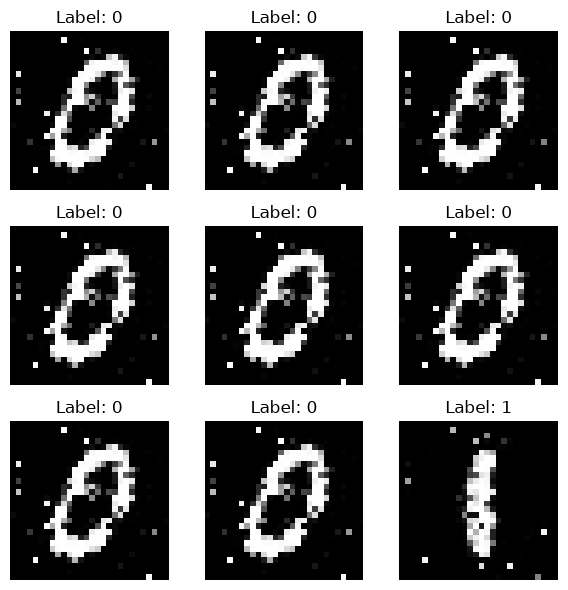

In [25]:
### Generate and visualize samples
def generate_samples(generator, n_classes=10, n_per_class=8):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_classes * n_per_class, z_dim).to(device)
        labels = torch.tensor([i for i in range(n_classes) for _ in range(n_per_class)]).to(device)
        gen_imgs = generator(z, labels)
    generator.train()
    return gen_imgs, labels

gen_imgs, gen_labels = generate_samples(generator)
show_batch(gen_imgs.cpu(), gen_labels.cpu(), n=10)

We can now see grids of digits 0–9, each set showing several synthetic examples.  
Each class label corresponds to the digit the Generator was conditioned on.

Even if the images look a bit fuzzy, the model has learned the *concept* of conditioning —  
the generator “knows” which class to produce.